# Exploratory Data Analysis of Airbnb Listings

**A descriptive, non-predictive analysis of a multi-city Airbnb dataset.**

This notebook explores an Airbnb listings dataset to uncover patterns, trends and
relationships among listing characteristics — focusing on **statistical summaries,
visualization, correlation analysis and interpretation** rather than building a
machine-learning prediction model.

**How to run:** open this folder in VS Code, select a Python kernel, and run all cells
top-to-bottom (`Run All`). Figures are written to the `figures/` folder as they are created.

## 1. Project Overview, Problem Statement, Aim & Objectives

**Problem statement.** Airbnb platforms contain large amounts of information about
properties — location, price, availability, reviews, ratings and host characteristics.
Raw listing data is difficult to interpret without systematic analysis. This project
explores the dataset to determine which characteristics are associated with differences
in listing **prices**, **availability** and **guest engagement**.

**Aim.** To conduct a systematic exploratory analysis of Airbnb listings and identify
important patterns, trends and relationships associated with price and availability.

**Objectives.** Understand the dataset structure; clean and preprocess the data; generate
descriptive statistics; study distributions of price, reviews, ratings and availability;
compare listings across cities and countries; measure correlations among numerical
variables; and present findings in a structured, evidence-based way.

### A note on adapting the project guide to *this* dataset

The generic EDA guide assumes a single-city dataset with columns such as `room_type`,
`minimum_nights`, `neighbourhood` and `reviews_per_month`. **This dataset does not contain
those columns.** Instead it is a **multi-city, multi-country** sample with `review_score`,
four availability windows, coordinates and an `amenities` list. The analysis has therefore
been faithfully adapted:

| Guide assumes | This dataset uses instead |
|---|---|
| `room_type` (categorical driver) | **`city` / `country`** (the geographic categorical driver) |
| `minimum_nights` | **availability windows** + **`review_score`** |
| `reviews_per_month` | **`no_of_reviews`** |
| `neighbourhood` | **`city`**, with `latitude` / `longitude` for geography |
| "calculated host listings count" | engineered **`host_listings_count`** (listings per `host_id`) |
| (n/a) | engineered **`amenities_count`** (number of amenities per listing) |

This substitution is documented rather than hidden, which is itself good analytical practice.

In [1]:
# --- Imports & configuration ---
import ast
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13

FIGDIR = Path("figures")
FIGDIR.mkdir(exist_ok=True)
DATA = Path("data/airbnb_dataset.csv")


def savefig(name: str):
    """Save the current figure to figures/ and display it."""
    plt.savefig(FIGDIR / name, dpi=150, bbox_inches="tight")


PRIMARY = "#2A6F97"     # blue
ACCENT = "#E29578"      # warm accent
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

## 2. Data Understanding — load & inspect

In [2]:
df_raw = pd.read_csv(DATA)
print("Raw shape:", df_raw.shape)
df_raw.head()

Raw shape: (4046, 19)


,Unnamed: 0,id,url,name,description,host_id,host_name,country,city,price,availability_30,availability_60,availability_90,availability_365,amenities,no_of_reviews,review_score,latitude,longitude
0,0,10006546,https://www.airbnb.com/rooms/10006546,Ribeira Charming Duplex,Fantastic duplex apartment with three bedrooms...,51399391,Ana&Gonçalo,Portugal,Porto,80.0,28,47,74,239,"['TV', 'Cable TV', 'Wifi', 'Kitchen', 'Paid pa...",51,9.0,41.141300,-8.613080
1,1,1001265,https://www.airbnb.com/rooms/1001265,Ocean View Waikiki Marina w/prkg,A short distance from Honolulu's billion dolla...,5448114,David,United States,Oahu,115.0,16,46,76,343,"['TV', 'Cable TV', 'Wifi', 'Air conditioning',...",96,9.0,21.286340,-157.839190
2,2,10021707,https://www.airbnb.com/rooms/10021707,Private Room in Bushwick,Here exists a very cozy room for rent in a sha...,11275734,Josh,United States,New York,40.0,0,0,0,0,"['Internet', 'Wifi', 'Air conditioning', 'Kitc...",1,8.0,40.697910,-73.936150
3,3,1003530,https://www.airbnb.com/rooms/1003530,New York City - Upper West Side Apt,"Murphy bed, optional second bedroom available....",454250,Greta,United States,New York,135.0,0,0,0,93,"['Internet', 'Wifi', 'Air conditioning', 'Kitc...",70,10.0,40.799620,-73.965230
4,4,10038496,https://www.airbnb.com/rooms/10038496,Copacabana Apartment Posto 6,"The Apartment has a living room, toilet, bedro...",51530266,Ana Valéria,Brazil,Rio De Janeiro,119.0,7,19,33,118,"['TV', 'Cable TV', 'Internet', 'Wifi', 'Air co...",70,10.0,-22.984339,-43.190849


In [3]:
# 'Unnamed: 0' is just an exported row index — drop it.
df = df_raw.drop(columns=["Unnamed: 0"])
print("Shape after dropping index column:", df.shape)
print("\nColumn dtypes:")
print(df.dtypes)

Shape after dropping index column: (4046, 18)

Column dtypes:
id                    int64
url                  object
name                 object
description          object
host_id               int64
host_name            object
country              object
city                 object
price               float64
availability_30       int64
availability_60       int64
availability_90       int64
availability_365      int64
amenities            object
no_of_reviews         int64
review_score        float64
latitude            float64
longitude           float64
dtype: object


In [4]:
# Structure and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4046 entries, 0 to 4045
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                4046 non-null   int64  
 1   url               4046 non-null   object 
 2   name              4046 non-null   object 
 3   description       4046 non-null   object 
 4   host_id           4046 non-null   int64  
 5   host_name         4046 non-null   object 
 6   country           4046 non-null   object 
 7   city              4046 non-null   object 
 8   price             4046 non-null   float64
 9   availability_30   4046 non-null   int64  
 10  availability_60   4046 non-null   int64  
 11  availability_90   4046 non-null   int64  
 12  availability_365  4046 non-null   int64  
 13  amenities         4046 non-null   object 
 14  no_of_reviews     4046 non-null   int64  
 15  review_score      4046 non-null   float64
 16  latitude          4046 non-null   float64


In [5]:
# Full descriptive summary (numeric + categorical)
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,4046.0,NaN,NaN,NaN,15310353.598122,9187858.522394,11708.0,7120754.5,15922358.0,22670647.5,32839070.0
url,4046,4046,https://www.airbnb.com/rooms/9993190,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,4046,4042,Feel like home,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,4046,4037,Urban Shadow It couldn’t be better located. Wa...,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,4046.0,NaN,NaN,NaN,57372619.670292,62733723.214125,2787.0,8539531.25,31276482.0,91290804.5,246729480.0
host_name,4046,2448,Maria,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,4046,9,United States,1061,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,4046,13,New York,532,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,4046.0,NaN,NaN,NaN,224.656204,399.019579,9.0,68.0,120.0,250.0,11681.0
availability_30,4046.0,NaN,NaN,NaN,10.786703,10.81359,0.0,0.0,7.0,20.0,30.0


### Missing values, duplicates and cardinality

In [6]:
print("Missing values per column:")
print(df.isnull().sum().sort_values(ascending=False))
print("\nExact duplicate rows:", df.duplicated().sum())
print("Duplicate listing ids:", df["id"].duplicated().sum())

Missing values per column:
id                  0
url                 0
name                0
description         0
host_id             0
host_name           0
country             0
city                0
price               0
availability_30     0
availability_60     0
availability_90     0
availability_365    0
amenities           0
no_of_reviews       0
review_score        0
latitude            0
longitude           0
dtype: int64

Exact duplicate rows: 0
Duplicate listing ids: 0


In [7]:
print("Unique values per column:")
print(df.nunique().sort_values(ascending=False))

Unique values per column:
id                  4046
url                 4046
name                4042
description         4037
amenities           4016
latitude            3923
longitude           3918
host_id             3765
host_name           2448
price                534
availability_365     366
no_of_reviews        258
availability_90       91
availability_60       61
availability_30       31
city                  13
country                9
review_score           9
dtype: int64


**Observation.** The dataset has **4,046 listings** and **18 substantive columns**, with
**no missing values** and **no duplicate rows or ids**. Columns fall into four groups:
identifiers/text (`id`, `url`, `name`, `description`, `host_id`, `host_name`, `amenities`),
geographic (`country`, `city`, `latitude`, `longitude`), and numeric behavioural/price
fields (`price`, four availability windows, `no_of_reviews`, `review_score`).

## 3. Data Cleaning & Feature Engineering

The data is already tidy (no missing values, no duplicates). The cleaning steps are
therefore light and are **documented explicitly**:

1. Dropped the exported index column `Unnamed: 0`.
2. **Engineered `amenities_count`** — parsed the `amenities` string (a Python-list literal)
   and counted items per listing.
3. **Engineered `host_listings_count`** — number of listings per `host_id` (a proxy for the
   guide's "calculated host listings count").
4. **Outliers kept, not deleted.** `price` is extremely right-skewed (max \$11,681). These
   are treated as legitimate luxury listings and retained for all statistics; for
   *visual* clarity, some plots are capped at the 99th percentile (this is a display choice
   only and is stated on each affected chart).

In [8]:
# 2 & 3 — feature engineering
df["amenities_count"] = df["amenities"].apply(
    lambda x: len(ast.literal_eval(x)) if isinstance(x, str) else np.nan
)
df["host_listings_count"] = df.groupby("host_id")["id"].transform("count")

# Sanity checks on impossible values
print("Negative or zero prices:", int((df["price"] <= 0).sum()))
print("Availability outside 0-365:",
      int(((df["availability_365"] < 0) | (df["availability_365"] > 365)).sum()))
print("review_score range:", df["review_score"].min(), "-", df["review_score"].max())

# Numeric columns used for statistics & correlation
NUMERIC = ["price", "availability_30", "availability_60", "availability_90",
           "availability_365", "no_of_reviews", "review_score",
           "amenities_count", "host_listings_count"]

# 99th-percentile cap for *visualisation only*
PRICE_CAP = df["price"].quantile(0.99)
print(f"\nPrice 99th percentile (visual cap): ${PRICE_CAP:,.0f}")
print(f"Listings above the cap (kept in stats, hidden in some plots): "
      f"{int((df['price'] > PRICE_CAP).sum())}")

Negative or zero prices: 0
Availability outside 0-365: 0
review_score range: 2.0 - 10.0

Price 99th percentile (visual cap): $1,393
Listings above the cap (kept in stats, hidden in some plots): 41


## 4. Descriptive Statistics

For skewed variables such as `price`, the **median and quartiles** are more representative
than the mean, because a small number of very expensive listings inflate the mean.

In [9]:
desc = df[NUMERIC].describe(percentiles=[0.25, 0.5, 0.75, 0.9]).T
desc = desc.round(2)
desc

,count,mean,std,min,25%,50%,75%,90%,max
price,4046.0,224.66,399.02,9.0,68.0,120.0,250.00,500.0,11681.0
availability_30,4046.0,10.79,10.81,0.0,0.0,7.0,20.00,29.0,30.0
availability_60,4046.0,24.73,21.84,0.0,0.0,21.0,45.00,58.0,60.0
availability_90,4046.0,40.65,32.95,0.0,4.0,40.0,71.00,88.0,90.0
availability_365,4046.0,171.63,134.43,0.0,31.0,169.0,306.00,355.0,365.0
no_of_reviews,4046.0,37.84,54.94,1.0,4.0,15.0,48.75,107.0,533.0
review_score,4046.0,9.31,0.93,2.0,9.0,9.0,10.00,10.0,10.0
amenities_count,4046.0,23.93,11.58,1.0,15.0,22.0,31.00,40.0,76.0
host_listings_count,4046.0,1.23,0.89,1.0,1.0,1.0,1.00,2.0,11.0


In [10]:
# Persist the descriptive table for the report
desc.to_csv("data/descriptive_statistics.csv")
print("Saved descriptive statistics table -> data/descriptive_statistics.csv")

Saved descriptive statistics table -> data/descriptive_statistics.csv


## 5. Univariate Analysis

We first study each variable on its own: the shape of its distribution, its typical value
and its spread.

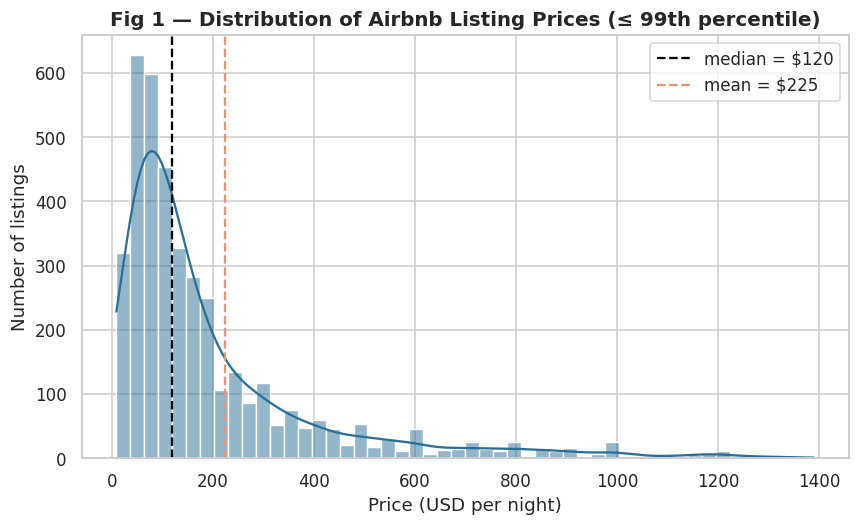

In [11]:
# Fig 01 — Price distribution (capped at 99th pct for readability)
fig, ax = plt.subplots()
sub = df.loc[df["price"] <= PRICE_CAP, "price"]
sns.histplot(sub, bins=50, kde=True, color=PRIMARY, ax=ax)
ax.axvline(df["price"].median(), color="black", ls="--", lw=1.5,
           label=f"median = ${df['price'].median():,.0f}")
ax.axvline(df["price"].mean(), color=ACCENT, ls="--", lw=1.5,
           label=f"mean = ${df['price'].mean():,.0f}")
ax.set_title("Fig 1 — Distribution of Airbnb Listing Prices (≤ 99th percentile)")
ax.set_xlabel("Price (USD per night)")
ax.set_ylabel("Number of listings")
ax.legend()
savefig("fig01_price_distribution.png")

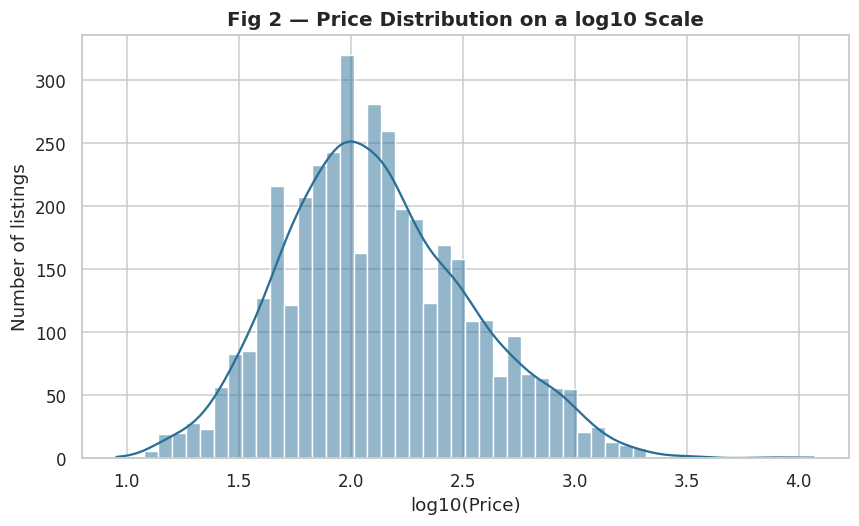

In [12]:
# Fig 02 — Price on a log scale (reveals the underlying shape past the skew)
fig, ax = plt.subplots()
sns.histplot(np.log10(df["price"]), bins=50, kde=True, color=PRIMARY, ax=ax)
ax.set_title("Fig 2 — Price Distribution on a log10 Scale")
ax.set_xlabel("log10(Price)")
ax.set_ylabel("Number of listings")
savefig("fig02_price_log_distribution.png")

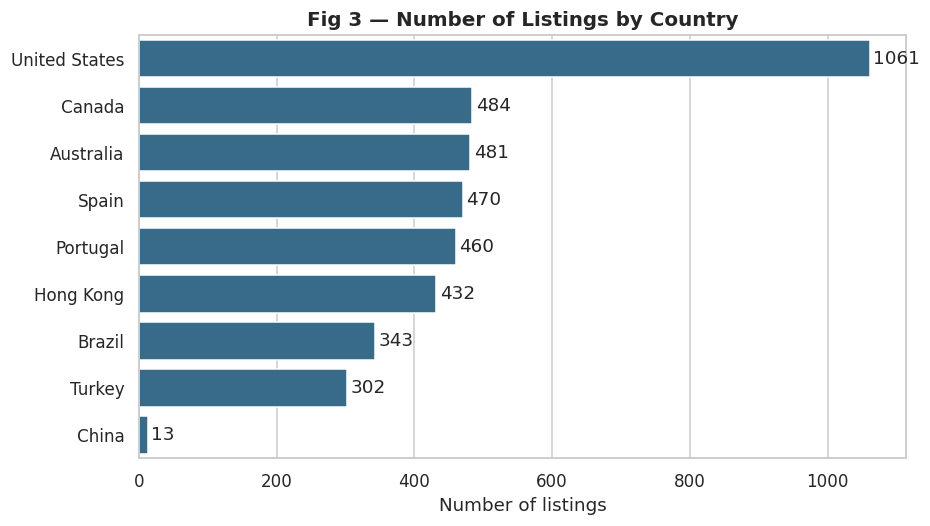

In [13]:
# Fig 03 — Listings by country
fig, ax = plt.subplots()
order = df["country"].value_counts()
sns.barplot(x=order.values, y=order.index, color=PRIMARY, ax=ax)
for i, v in enumerate(order.values):
    ax.text(v + 5, i, str(v), va="center")
ax.set_title("Fig 3 — Number of Listings by Country")
ax.set_xlabel("Number of listings")
ax.set_ylabel("")
savefig("fig03_listings_by_country.png")

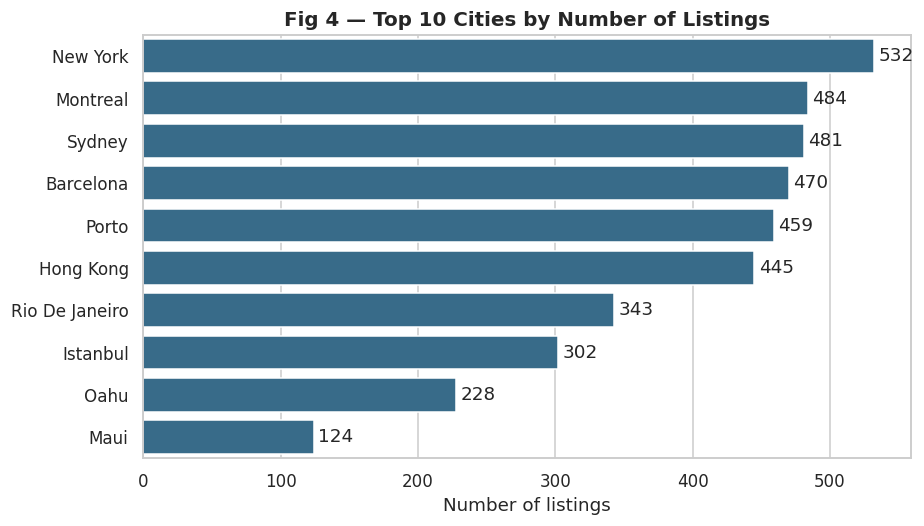

In [14]:
# Fig 04 — Top cities by number of listings
fig, ax = plt.subplots()
top_cities = df["city"].value_counts().head(10)
sns.barplot(x=top_cities.values, y=top_cities.index, color=PRIMARY, ax=ax)
for i, v in enumerate(top_cities.values):
    ax.text(v + 3, i, str(v), va="center")
ax.set_title("Fig 4 — Top 10 Cities by Number of Listings")
ax.set_xlabel("Number of listings")
ax.set_ylabel("")
savefig("fig04_top_cities_by_listings.png")

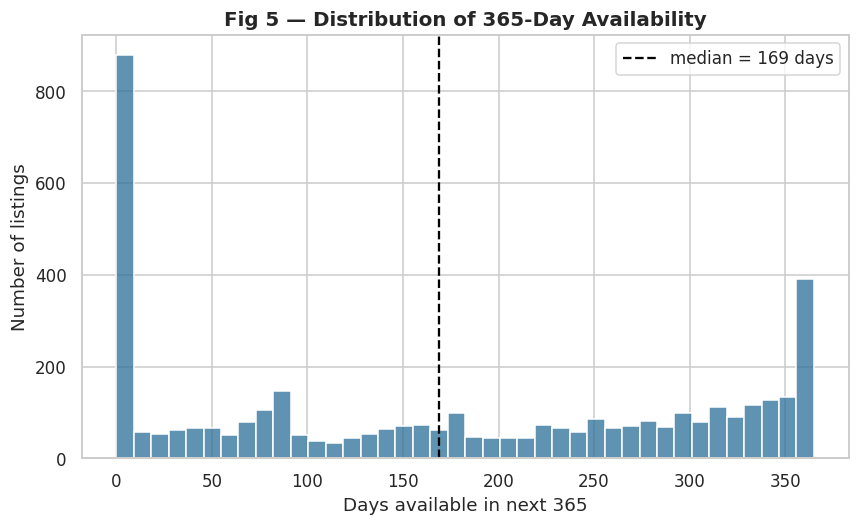

In [15]:
# Fig 05 — Availability (next 365 days)
fig, ax = plt.subplots()
sns.histplot(df["availability_365"], bins=40, color=PRIMARY, ax=ax)
ax.axvline(df["availability_365"].median(), color="black", ls="--",
           label=f"median = {df['availability_365'].median():.0f} days")
ax.set_title("Fig 5 — Distribution of 365-Day Availability")
ax.set_xlabel("Days available in next 365")
ax.set_ylabel("Number of listings")
ax.legend()
savefig("fig05_availability365_distribution.png")

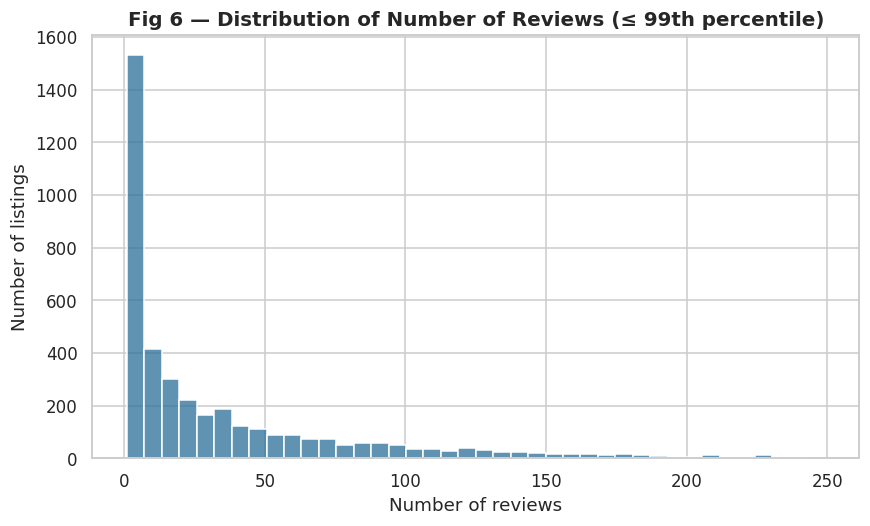

In [16]:
# Fig 06 — Number of reviews (capped at 99th pct for readability)
fig, ax = plt.subplots()
rc = df["no_of_reviews"].quantile(0.99)
sns.histplot(df.loc[df["no_of_reviews"] <= rc, "no_of_reviews"], bins=40,
             color=PRIMARY, ax=ax)
ax.set_title("Fig 6 — Distribution of Number of Reviews (≤ 99th percentile)")
ax.set_xlabel("Number of reviews")
ax.set_ylabel("Number of listings")
savefig("fig06_reviews_distribution.png")

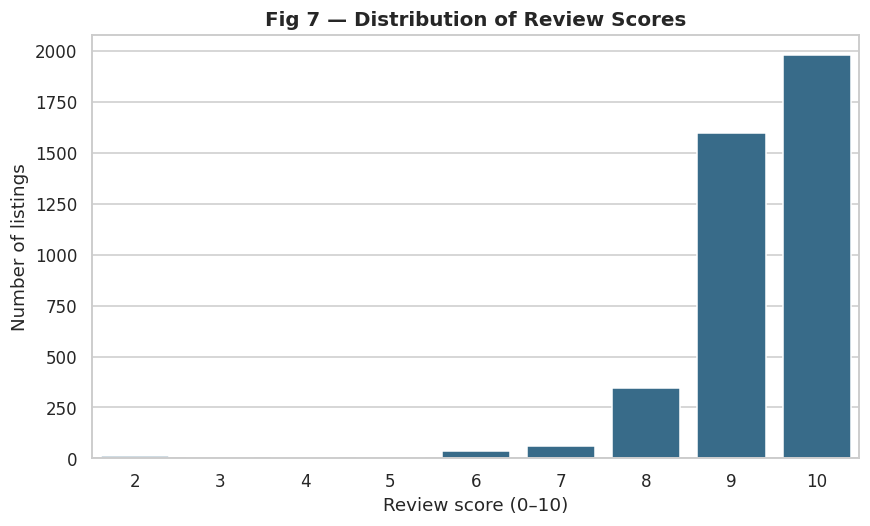

In [17]:
# Fig 07 — Review score
fig, ax = plt.subplots()
vc = df["review_score"].value_counts().sort_index()
sns.barplot(x=vc.index.astype(int).astype(str), y=vc.values, color=PRIMARY, ax=ax)
ax.set_title("Fig 7 — Distribution of Review Scores")
ax.set_xlabel("Review score (0–10)")
ax.set_ylabel("Number of listings")
savefig("fig07_review_score_distribution.png")

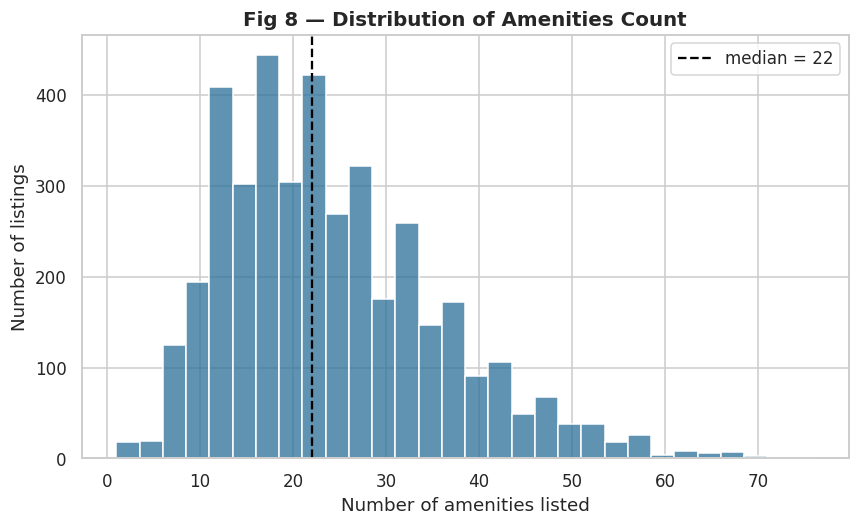

In [18]:
# Fig 08 — Amenities count
fig, ax = plt.subplots()
sns.histplot(df["amenities_count"], bins=30, color=PRIMARY, ax=ax)
ax.axvline(df["amenities_count"].median(), color="black", ls="--",
           label=f"median = {df['amenities_count'].median():.0f}")
ax.set_title("Fig 8 — Distribution of Amenities Count")
ax.set_xlabel("Number of amenities listed")
ax.set_ylabel("Number of listings")
ax.legend()
savefig("fig08_amenities_count_distribution.png")

### Univariate interpretation

**Price (Figs 1–2) — Observation:** prices span \$9 to \$11,681 but are **extremely
right-skewed** (skewness ≈ 13.5). The **median is \$120** while the **mean is \$225**,
and the middle 50% of listings fall between **\$68 and \$250**; about **9.9%** exceed \$500.
*Interpretation:* a handful of luxury listings drag the mean well above the median, so the
median is the honest measure of a "typical" price. *Implication:* every cross-group price
comparison below uses **medians**, and the long luxury tail is acknowledged, not deleted.

**Location (Figs 3–4) — Observation:** the **United States** has the most listings
(1,061; ~26%) and **New York** is the largest single city (532); the other countries are
fairly balanced (~300–490), with **China a tiny slice (13)**. *Interpretation:* this is a
curated multi-city sample, not a census, and NY/US are over-represented. *Implication:*
global aggregates blend very different markets and should be read with that in mind.

**Availability (Fig 5) — Observation:** median availability is **169 days**; **18.8%** of
listings show **0 days** available while **162** are open all 365. *Interpretation:* the
zero-availability block likely reflects blocked/inactive calendars or fully-booked hosts.
*Implication:* availability is heterogeneous and partly a calendar artifact.

**Reviews & ratings (Figs 6–7) — Observation:** `no_of_reviews` is right-skewed
(median 15, mean 38, max 533), and `review_score` shows a strong **ceiling effect** —
**88.4%** of listings score **≥9** and 97% score ≥8. *Interpretation:* most listings are
rated near the top, so ratings carry little discriminating information. *Implication:*
`review_score` will have limited power to explain price differences.

**Amenities (Fig 8) — Observation:** listings offer a median of **22** amenities
(range 1–76). *Interpretation:* meaningful variation in richness of offering.
*Implication:* a plausible differentiator to test against price (done below).

## 6. Bivariate & Multivariate Analysis

We now examine relationships **between** variables, focusing on what is associated with price.

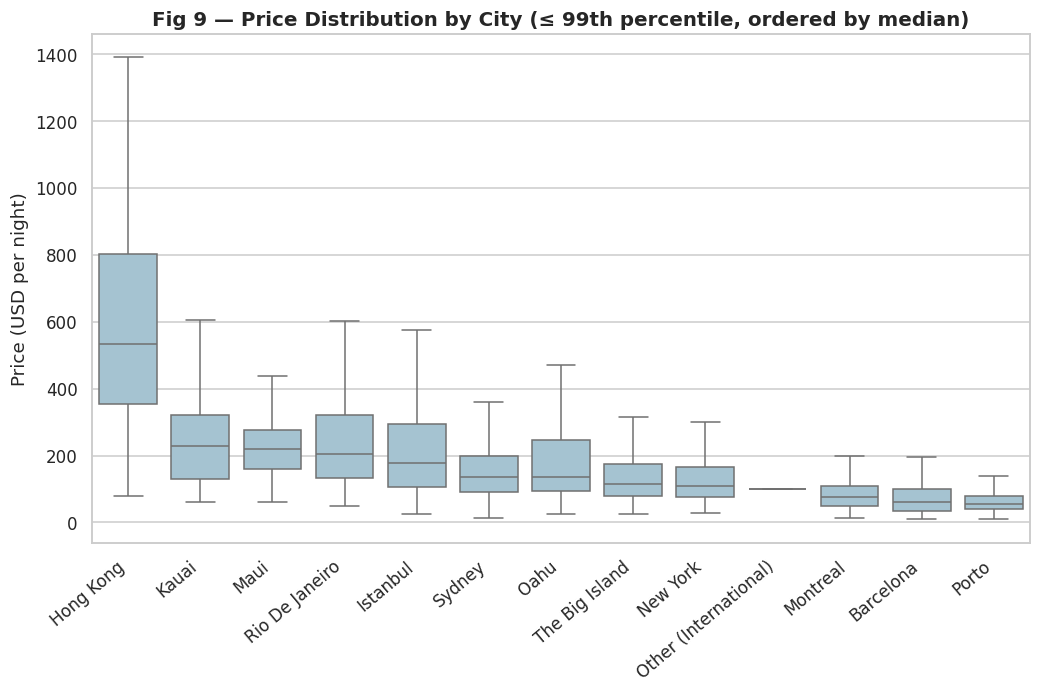

In [19]:
# Fig 09 — Price by city (boxplot, ordered by median; y capped for readability)
fig, ax = plt.subplots(figsize=(11, 6))
city_order = df.groupby("city")["price"].median().sort_values(ascending=False).index
sns.boxplot(data=df[df["price"] <= PRICE_CAP], x="city", y="price",
            order=city_order, color="#9EC5D8", showfliers=False, ax=ax)
ax.set_title("Fig 9 — Price Distribution by City (≤ 99th percentile, ordered by median)")
ax.set_xlabel("")
ax.set_ylabel("Price (USD per night)")
ax.tick_params(axis="x", rotation=40)
plt.setp(ax.get_xticklabels(), ha="right")
savefig("fig09_price_by_city_box.png")

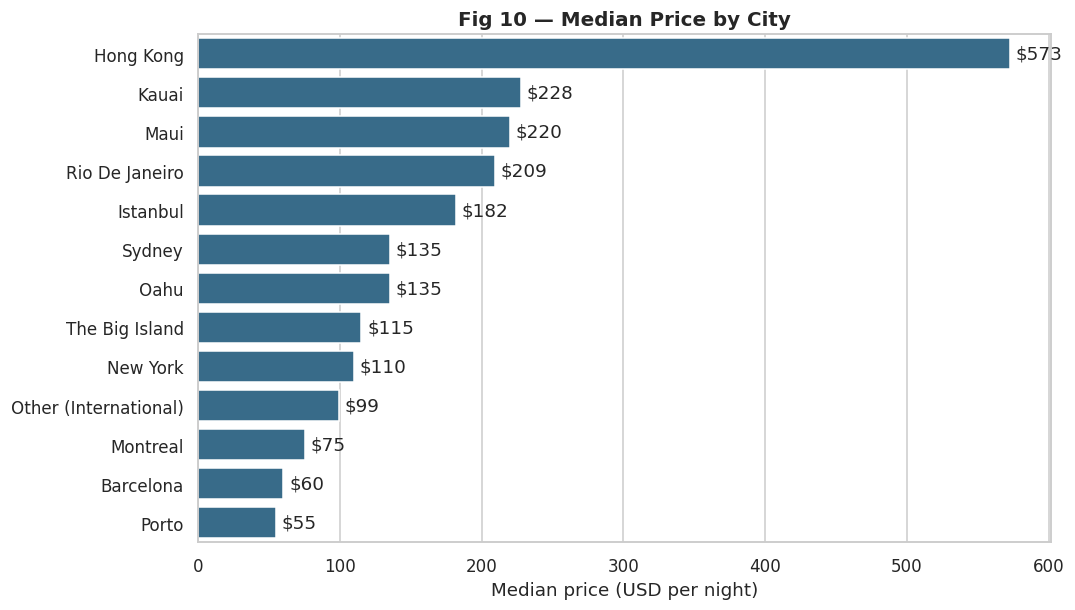

In [20]:
# Fig 10 — Median price by city
fig, ax = plt.subplots(figsize=(10, 6))
med_city = df.groupby("city")["price"].median().sort_values(ascending=False)
sns.barplot(x=med_city.values, y=med_city.index, color=PRIMARY, ax=ax)
for i, v in enumerate(med_city.values):
    ax.text(v + 4, i, f"${v:,.0f}", va="center")
ax.set_title("Fig 10 — Median Price by City")
ax.set_xlabel("Median price (USD per night)")
ax.set_ylabel("")
savefig("fig10_median_price_by_city.png")

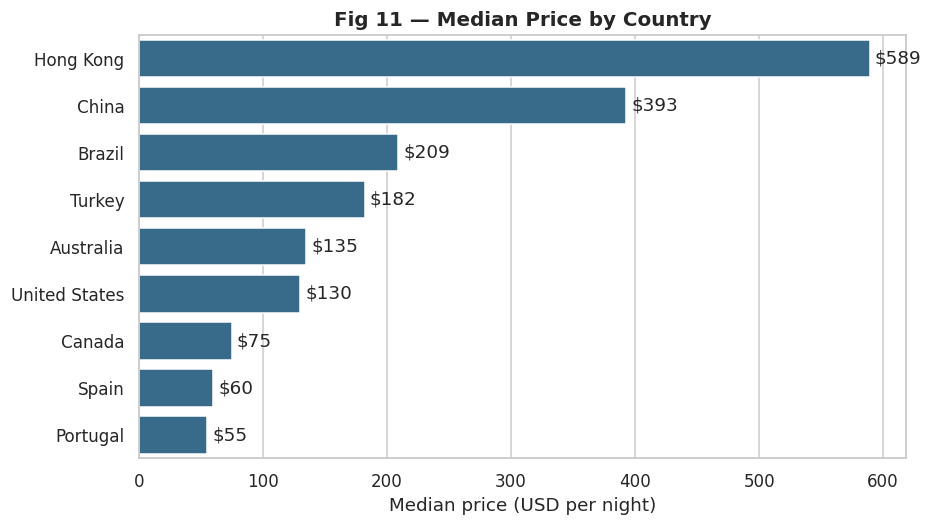

In [21]:
# Fig 11 — Median price by country
fig, ax = plt.subplots()
med_ctry = df.groupby("country")["price"].median().sort_values(ascending=False)
sns.barplot(x=med_ctry.values, y=med_ctry.index, color=PRIMARY, ax=ax)
for i, v in enumerate(med_ctry.values):
    ax.text(v + 4, i, f"${v:,.0f}", va="center")
ax.set_title("Fig 11 — Median Price by Country")
ax.set_xlabel("Median price (USD per night)")
ax.set_ylabel("")
savefig("fig11_median_price_by_country.png")

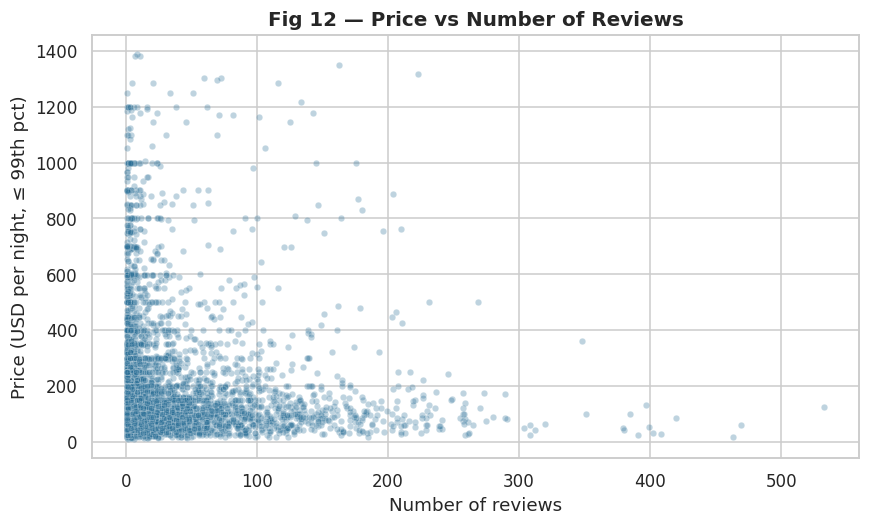

In [22]:
# Fig 12 — Price vs number of reviews (association, not causation)
fig, ax = plt.subplots()
sns.scatterplot(data=df[df["price"] <= PRICE_CAP], x="no_of_reviews", y="price",
                alpha=0.3, s=18, color=PRIMARY, ax=ax)
ax.set_title("Fig 12 — Price vs Number of Reviews")
ax.set_xlabel("Number of reviews")
ax.set_ylabel("Price (USD per night, ≤ 99th pct)")
savefig("fig12_price_vs_reviews.png")

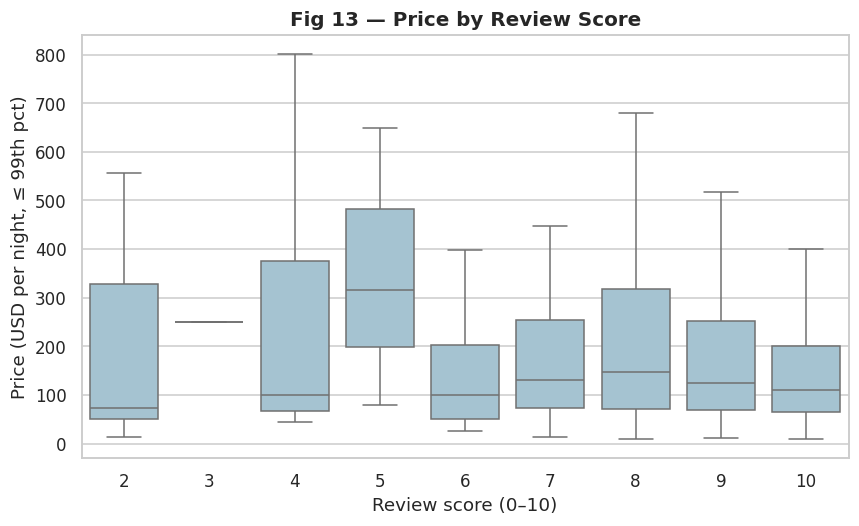

In [23]:
# Fig 13 — Price by review score (box)
fig, ax = plt.subplots()
sns.boxplot(data=df[df["price"] <= PRICE_CAP], x=df["review_score"].astype(int),
            y="price", color="#9EC5D8", showfliers=False, ax=ax)
ax.set_title("Fig 13 — Price by Review Score")
ax.set_xlabel("Review score (0–10)")
ax.set_ylabel("Price (USD per night, ≤ 99th pct)")
savefig("fig13_price_by_review_score.png")

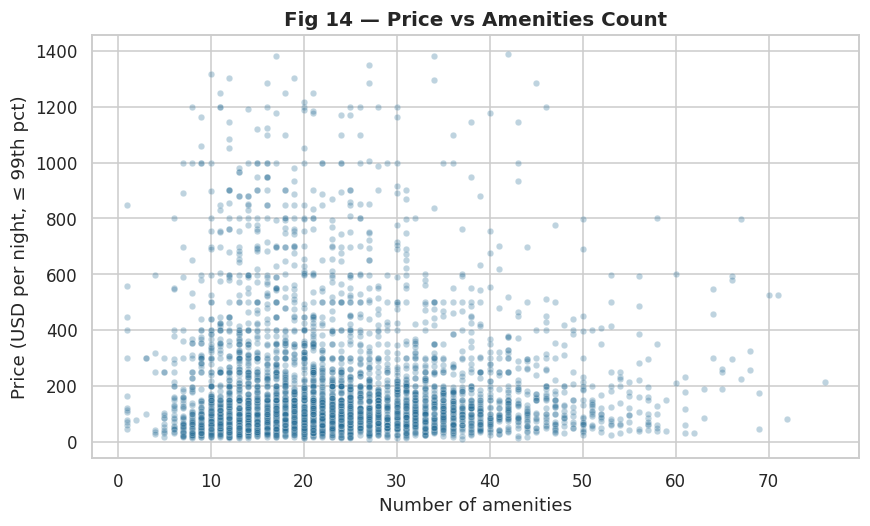

In [24]:
# Fig 14 — Price vs amenities count
fig, ax = plt.subplots()
sns.scatterplot(data=df[df["price"] <= PRICE_CAP], x="amenities_count", y="price",
                alpha=0.3, s=18, color=PRIMARY, ax=ax)
ax.set_title("Fig 14 — Price vs Amenities Count")
ax.set_xlabel("Number of amenities")
ax.set_ylabel("Price (USD per night, ≤ 99th pct)")
savefig("fig14_price_vs_amenities.png")

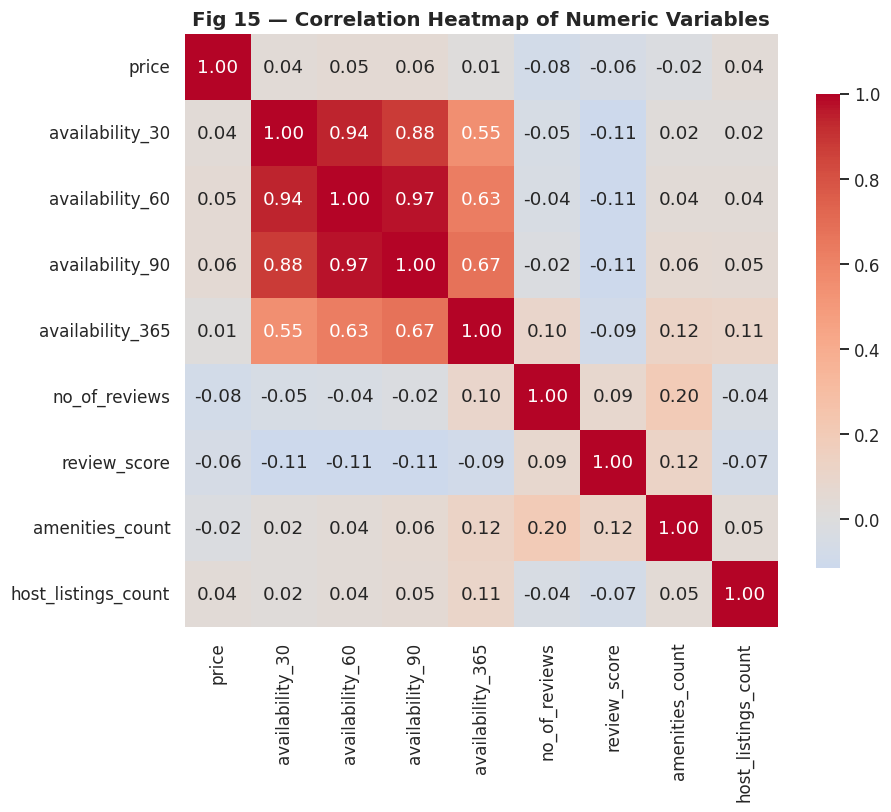

In [25]:
# Fig 15 — Correlation heatmap (numeric variables)
fig, ax = plt.subplots(figsize=(9, 7))
corr = df[NUMERIC].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Fig 15 — Correlation Heatmap of Numeric Variables")
savefig("fig15_correlation_heatmap.png")

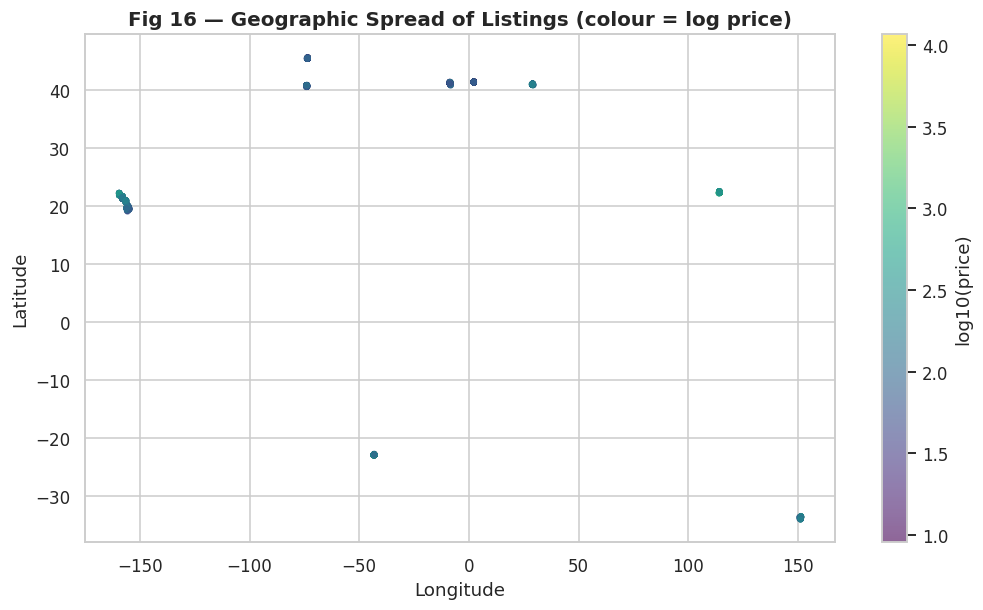

In [26]:
# Fig 16 — Geographic scatter, coloured by log price
fig, ax = plt.subplots(figsize=(11, 6))
sc = ax.scatter(df["longitude"], df["latitude"], c=np.log10(df["price"]),
                cmap="viridis", s=10, alpha=0.6)
cb = plt.colorbar(sc, ax=ax)
cb.set_label("log10(price)")
ax.set_title("Fig 16 — Geographic Spread of Listings (colour = log price)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
savefig("fig16_geographic_scatter.png")

### Bivariate / multivariate interpretation

**Price by location (Figs 9–11) — Observation:** median price ranges from **\$55 in
Porto** to **\$573 in Hong Kong** — a **>10× spread** across cities; by country, Hong Kong
(\$589) and China (\$393) top the list while Portugal (\$55) and Spain (\$60) sit at the
bottom. *Interpretation:* **location is the dominant axis of price variation** in this
dataset. *Implication:* a single global "typical price" is misleading; price insights must
condition on city/country.

**Price vs numeric attributes (Figs 12–14) — Observation:** the scatterplots show **no
visible trend** — price does not rise or fall clearly with review count, review score or
amenity count. *Interpretation:* within this sample the numeric listing attributes are
essentially unrelated to price. *Implication:* the drivers of price are locational and
structural (city, exact location, size, property type) rather than these measured fields.

**Correlation (Fig 15) — Observation:** the **strongest** linear correlation with price is
only **−0.079** (`no_of_reviews`); every |r| is **< 0.08**. The availability windows
correlate strongly *with each other* (as expected) but not with price. *Interpretation:*
there is **essentially no linear association** between price and the available numeric
variables. **Correlation ≠ causation** — and here even the association itself is negligible.
*Implication:* a price model built from these numeric features alone would perform poorly;
the usable signal lives in the categorical location fields.

**Geography (Fig 16) — Observation:** listings form distinct city clusters worldwide, with
higher log-prices concentrated in specific clusters (e.g. Hong Kong). *Interpretation:*
reinforces the location-driven price story visually.

## 7. Key Findings — answering the analytical questions

1. **Structure:** 4,046 listings × 18 substantive columns — identifiers/text, geographic,
   and numeric behavioural/price fields.
2. **Data quality:** no missing values and no duplicate rows or listing ids.
3. **Price distribution:** strongly right-skewed; **median \$120**, mean \$225, IQR \$68–\$250.
4. **Room type:** *not present* in this dataset; the equivalent structural dimension is
   **location**, where the US / New York dominate listing counts.
5. **Most listings:** **New York** (city, 532) and the **United States** (country, 1,061).
6. **Highest typical price:** **Hong Kong** — median **\$573** (city) / **\$589** (country).
7. **Location vs price** (replacing room-type vs price): a **>10×** spread in median price
   across cities (\$55 Porto → \$573 Hong Kong).
8. **Reviews vs price:** negligible negative correlation (**−0.079**) — no meaningful link.
9. **Minimum stay vs price:** *not available*; the nearest proxies (`review_score`,
   availability) are also essentially uncorrelated with price (|r| < 0.06).
10. **Availability across locations:** varies widely — **Istanbul** highest (median 331 days),
    **Sydney** lowest (median 65 days).
11. **Most price-correlated numeric variable:** none is meaningful; the largest magnitude is
    `no_of_reviews` at **−0.079**.
12. **Major insight:** **price is driven overwhelmingly by location**; the numeric listing
    attributes are near-uncorrelated with price, and review scores show a strong ceiling
    effect (88% ≥ 9).

## 8. Limitations

- The dataset is a **curated multi-city sample**, not a full census of any market; the US and
  New York are over-represented and **China is tiny (n = 13)**, so its statistics are unstable.
- `review_score` exhibits a **ceiling effect** (most values 9–10), limiting its analytical value.
- Extreme prices are retained as **legitimate luxury listings**, but they still influence means.
- The data is a **cross-sectional snapshot**; no time dimension, seasonality or booking history.
- Key structural price drivers that are usually decisive — **room/property type, size,
  exact neighbourhood, minimum nights** — are **not in this dataset**, which partly explains
  the weak numeric correlations with price.
- **Correlation does not imply causation**, and here associations are in any case negligible.

## 9. Conclusion

This project performed a descriptive exploratory analysis of 4,046 Airbnb listings across
9 countries and 13 cities. Prices are strongly right-skewed (median \$120), so medians and
quartiles were used throughout. The clearest and most robust pattern is that **listing price
is associated above all with location**: median city prices span more than ten-fold, from
\$55 in Porto to \$573 in Hong Kong. In contrast, the available **numeric attributes —
review count, review score, availability and amenity count — are essentially uncorrelated
with price** (all |r| < 0.08), and review scores are compressed near the top of their scale.
Overall, the analysis shows how exploratory data analysis turns raw accommodation data into
interpretable insight, while being candid about what the dataset can and cannot reveal.

In [27]:
# Save a cleaned analysis dataset for reproducibility
df.to_csv("data/airbnb_cleaned.csv", index=False)
print("Saved cleaned dataset -> data/airbnb_cleaned.csv  |  shape:", df.shape)

Saved cleaned dataset -> data/airbnb_cleaned.csv  |  shape: (4046, 20)
